# Module 4: Data Visualization
## Notebook 1: Static Plotting with Matplotlib and Seaborn

**Responsible partner:** FERIT Osijek, Croatia — Mario Dudjak (`mario.dudjak@ferit.hr`)  
**GitHub:** `MarioDudjak` / `dudjakmario@hotmail.com`

**Estimated duration:** 50–60 minutes


## 1. How to use this notebook

This notebook is written for learners with little or no previous experience in data visualization.
The goal is not to cover every plotting option, but to build confidence with a few important plot types that are often used in environmental and scientific work.

You are encouraged to:
- run every code cell,
- read the explanation before each example,
- modify the code and observe what changes,
- complete the guided practice tasks at the end.


## 2. Learning goals

By the end of this notebook, you should be able to:
- create simple static plots using Matplotlib and Seaborn,
- choose between a line plot and a bar plot for basic communication tasks,
- improve readability with titles, labels, legends, and figure size,
- prepare clear figures for reports, presentations, and scientific communication.


## 3. Why do we visualize data?

A good visualization helps us understand data quickly.  
In environmental and scientific work, visualizations are often used to:
- inspect temporal trends,
- compare measurements across locations,
- detect unusual values,
- communicate findings to others.

In this notebook, we will focus on **static plots**.  
A static plot is a figure that does not require interaction and can be inserted into a report, article, or presentation.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

np.random.seed(42)


## 4. A first line plot

A **line plot** is useful when values are ordered, especially over time.

Let us create a simple example with monthly air temperature values.


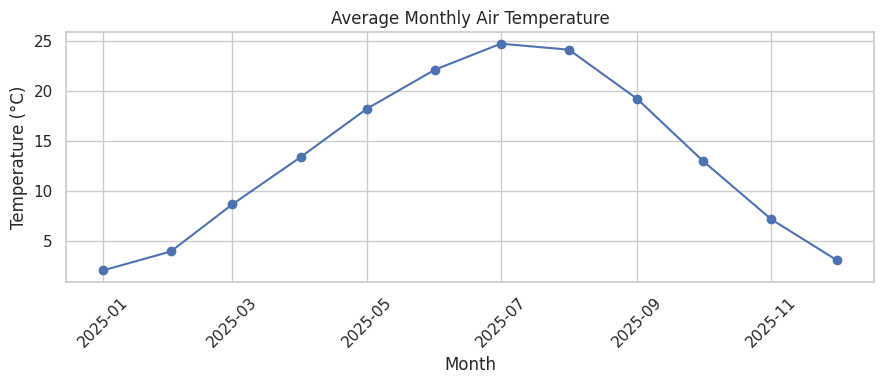

In [2]:
months = pd.date_range("2025-01-01", periods=12, freq="MS")
temperature = [2.1, 4.0, 8.7, 13.4, 18.2, 22.1, 24.7, 24.1, 19.2, 13.0, 7.2, 3.1]

plt.figure(figsize=(9, 4))
plt.plot(months, temperature, marker="o")
plt.title("Average Monthly Air Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Interpretation and discussion

This figure shows a clear seasonal pattern:
- lower temperatures in winter,
- higher temperatures in summer,
- a gradual rise and fall through the year.

This is a simple example, but the same logic can be used for pollutant concentration, river flow, humidity, or energy consumption.


## 5. Improving plot readability

A plot should not only exist — it should be easy to read.

Useful improvements include:
- choosing an appropriate figure size,
- adding informative labels,
- rotating crowded date labels,
- using markers when there are relatively few observations,
- avoiding overly decorative formatting.


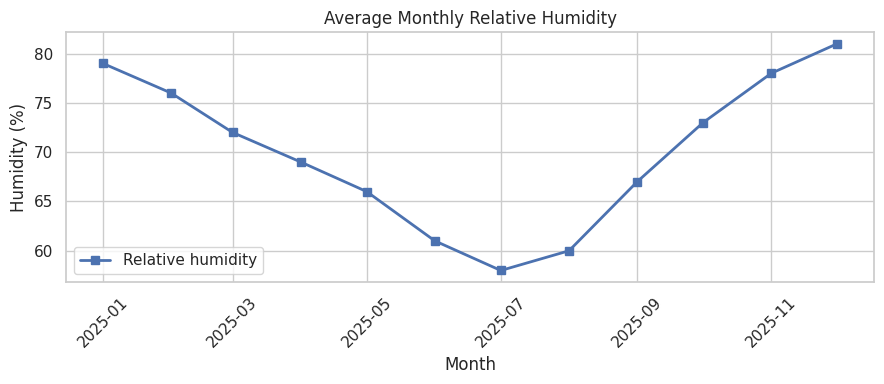

In [3]:
humidity = [79, 76, 72, 69, 66, 61, 58, 60, 67, 73, 78, 81]

plt.figure(figsize=(9, 4))
plt.plot(months, humidity, marker="s", linewidth=2, label="Relative humidity")
plt.title("Average Monthly Relative Humidity")
plt.xlabel("Month")
plt.ylabel("Humidity (%)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Comparing two variables on the same plot

Sometimes we want to compare two time series measured on the same time scale.

For example, we may want to compare temperature and particulate matter concentration.


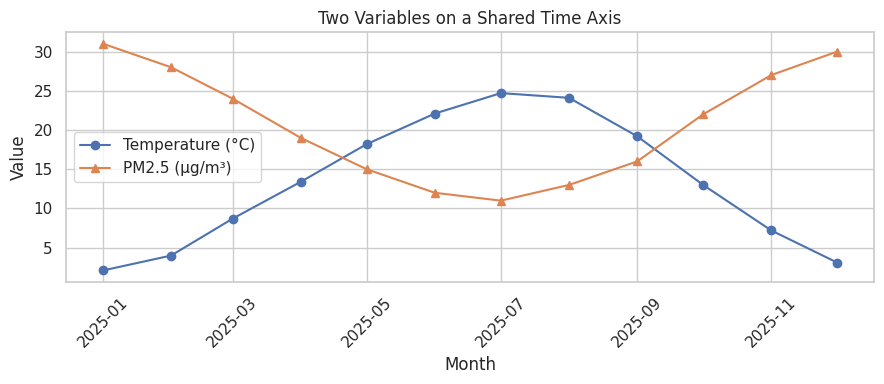

In [4]:
pm25 = [31, 28, 24, 19, 15, 12, 11, 13, 16, 22, 27, 30]

plt.figure(figsize=(9, 4))
plt.plot(months, temperature, marker="o", label="Temperature (°C)")
plt.plot(months, pm25, marker="^", label="PM2.5 (µg/m³)")
plt.title("Two Variables on a Shared Time Axis")
plt.xlabel("Month")
plt.ylabel("Value")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Important note

This type of comparison is useful, but only when the shared y-axis still makes sense.

If the variables are on very different scales, the figure can be misleading.  
In beginner courses, it is often better to start with simple shared-axis figures and discuss scale carefully.


## 5. Bar plots for categorical comparisons

A **bar plot** is useful when comparing values across categories.

Example: average NO$_2$ concentration measured at different stations.


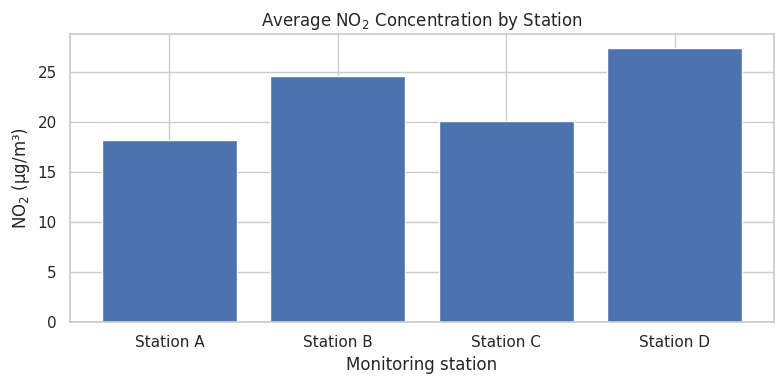

In [5]:
stations = ["Station A", "Station B", "Station C", "Station D"]
no2 = [18.2, 24.6, 20.1, 27.4]

plt.figure(figsize=(8, 4))
plt.bar(stations, no2)
plt.title("Average NO$_2$ Concentration by Station")
plt.xlabel("Monitoring station")
plt.ylabel("NO$_2$ (µg/m³)")
plt.tight_layout()
plt.show()


### Interpretation and discussion

This plot makes it easy to compare stations.

Bar plots are appropriate when:
- the x-axis represents categories,
- the y-axis represents a count, mean, or another summary value,
- the goal is comparison rather than showing every individual observation.


## 6. Creating a DataFrame for plotting

In real work, data are usually stored in a table rather than separate Python lists.


In [6]:
air_quality = pd.DataFrame({
    "month": months,
    "temperature": temperature,
    "humidity": humidity,
    "pm25": pm25
})

air_quality


,month,temperature,humidity,pm25
0,2025-01-01,2.1,79,31
1,2025-02-01,4.0,76,28
2,2025-03-01,8.7,72,24
3,2025-04-01,13.4,69,19
4,2025-05-01,18.2,66,15
5,2025-06-01,22.1,61,12
6,2025-07-01,24.7,58,11
7,2025-08-01,24.1,60,13
8,2025-09-01,19.2,67,16
9,2025-10-01,13.0,73,22


With a DataFrame, plotting becomes easier and more systematic.


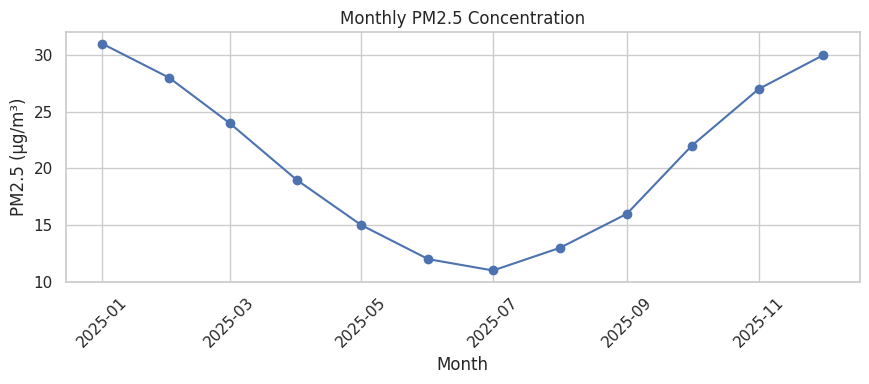

In [7]:
plt.figure(figsize=(9, 4))
plt.plot(air_quality["month"], air_quality["pm25"], marker="o")
plt.title("Monthly PM2.5 Concentration")
plt.xlabel("Month")
plt.ylabel("PM2.5 (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 7. Using Seaborn for simpler styling

**Seaborn** is built on top of Matplotlib.  
It provides a cleaner default style and convenient plotting functions.

Let us use Seaborn to create the same bar plot.


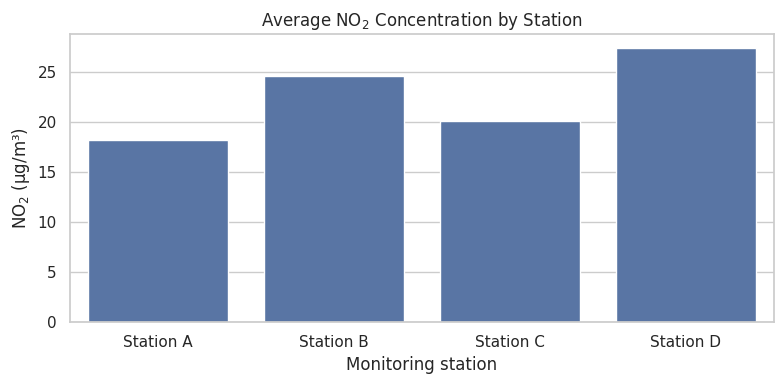

In [8]:
station_data = pd.DataFrame({
    "station": stations,
    "no2": no2
})

plt.figure(figsize=(8, 4))
sns.barplot(data=station_data, x="station", y="no2", color="C0")
plt.title("Average NO$_2$ Concentration by Station")
plt.xlabel("Monitoring station")
plt.ylabel("NO$_2$ (µg/m³)")
plt.tight_layout()
plt.show()


Seaborn is often helpful because:
- the default styling is attractive,
- the syntax works well with DataFrames,
- many statistical plots are easier to create.

Still, it is useful to learn the basic Matplotlib workflow first.


## 8. A slightly more realistic example: daily time series

Now let us create a simple daily dataset and visualize a temporal trend.


In [9]:
days = pd.date_range("2025-03-01", periods=14, freq="D")
ozone = np.array([41, 39, 42, 40, 38, 37, 35, 36, 39, 43, 44, 46, 45, 47])

daily_data = pd.DataFrame({
    "date": days,
    "ozone": ozone
})

daily_data.head()


,date,ozone
0,2025-03-01,41
1,2025-03-02,39
2,2025-03-03,42
3,2025-03-04,40
4,2025-03-05,38


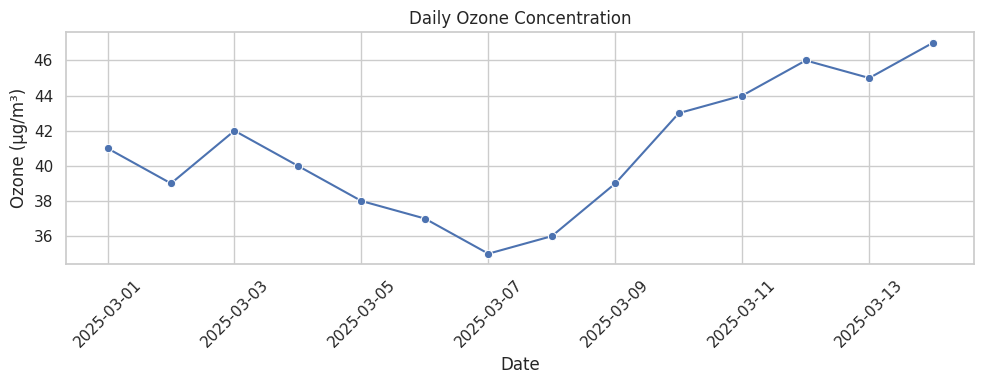

In [10]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=daily_data, x="date", y="ozone", marker="o")
plt.title("Daily Ozone Concentration")
plt.xlabel("Date")
plt.ylabel("Ozone (µg/m³)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 11. Practical advice for publication-quality static plots

A figure does not need to be complex to be useful.  
In many cases, a simple figure is the best figure.

Good practice includes:
1. Use an informative title.
2. Label both axes clearly.
3. Include units whenever relevant.
4. Avoid overcrowding the figure.
5. Use readable font sizes.
6. Keep colors and styles consistent.
7. Make sure the plot answers a clear question.


## 12. Guided practice

Try the following tasks:
1. Create a line plot for `temperature`.
2. Create a line plot for `humidity`.
3. Create a plot with both variables on the same figure.
4. Create a bar plot for station-level NO$_2$ values.
5. Change the title and axis labels to make the figure more informative.


In [11]:
# Write your code here.


## 13. Mini exercise

Create a DataFrame with:
- 7 consecutive days,
- one column for rainfall,
- one column for wind speed.

Then:
- plot rainfall as a line plot,
- create a second plot for wind speed,
- add appropriate labels and a title.


In [12]:
# Write your code here.


## 14. Summary

In this notebook, you learned how to:
- create line and bar plots,
- work with dates on the x-axis,
- improve figure readability,
- use both Matplotlib and Seaborn,
- produce simple static figures for environmental datasets.

In the next notebook, we will move from basic plotting to:
- histograms,
- boxplots,
- scatter plots,
- correlation heatmaps,
- and categorical comparison plots.
